# Boucle d'entraînement MNIST pour la colonne corticale

Ce notebook implémente une boucle d'entraînement supervisée par classe sur MNIST, puis évalue la qualité de la représentation SDR produite par `SpatialPooler`.

Objectifs :
- apprentissage hebbien local sur 5 000 images MNIST
- classification par plus proche voisin SDR
- comparaison des overlaps inter-classes avant / après apprentissage
- test de capacité sans collision pour des SDR aléatoires
- bilan final synthétique

# 0. Setup

On suit le même pattern que `MNIST_test.ipynb` : clonage du dépôt, installation des dépendances, puis imports et reproductibilité.

In [ ]:
import os
import subprocess
import sys
import importlib
from pathlib import Path

REPO_URL = "https://github.com/Baptistecaille/Cortical-Column.git"
REPO_DIR = "./Cortical-Column"
BRANCH = "main"

if not os.path.isdir(REPO_DIR):
    subprocess.run(
        ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, REPO_DIR],
        check=True,
    )
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "pull", "origin", BRANCH], check=True)

os.chdir(REPO_DIR)

module_path = Path("cortical_column.py")
old_block = """from .sdr_space import SDRSpace
from .spatial_pooler import SpatialPooler
from .layer6b import Layer6bTransformer
from .grid_cells import GridCellNetwork
from .displacement import DisplacementAlgebra
from .consensus import MultiColumnConsensus
"""
new_block = """try:
    from .sdr_space import SDRSpace
    from .spatial_pooler import SpatialPooler
    from .layer6b import Layer6bTransformer
    from .grid_cells import GridCellNetwork
    from .displacement import DisplacementAlgebra
    from .consensus import MultiColumnConsensus
except ImportError:
    from sdr_space import SDRSpace
    from spatial_pooler import SpatialPooler
    from layer6b import Layer6bTransformer
    from grid_cells import GridCellNetwork
    from displacement import DisplacementAlgebra
    from consensus import MultiColumnConsensus
"""
source = module_path.read_text()
if old_block in source:
    module_path.write_text(source.replace(old_block, new_block, 1))
    importlib.invalidate_caches()
    sys.modules.pop("cortical_column", None)
    print("Patched cortical_column.py for notebook-friendly imports.")
else:
    print("cortical_column.py already compatible or patch not needed.")

requirements = Path("requirements.txt")
if requirements.exists():
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    for pkg in ["torch", "torchvision", "matplotlib", "numpy", "seaborn"]:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", pkg, "--break-system-packages"],
            check=True,
        )

print("Working directory:", os.getcwd())
print("Branch:", BRANCH)
print("Dependencies installed.")

In [18]:
# ═══ Imports, graine et données MNIST ═══
import copy
import math
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torchvision
import torchvision.transforms as transforms

from cortical_column import CorticalColumn, SDRSpace, SpatialPooler

sns.set_theme(style="whitegrid", context="notebook")
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# On reste sur CPU pour garder la reproductibilité maximale du notebook.
DEVICE = torch.device("cpu")
print(f"PyTorch {torch.__version__} | Device : {DEVICE}")

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, transform=transform, download=True
)

print(f"Train : {len(train_dataset)} images")
print(f"Test  : {len(test_dataset)} images")


def mnist_to_bool(img_tensor: torch.Tensor, threshold: float = 0.2) -> torch.BoolTensor:
    """
    Déf. 2.6 : binarisation simple de MNIST avant encodage hebbien.

    On transforme une image (1, 28, 28) en vecteur booléen (784,).
    """
    return (img_tensor.view(-1) > threshold)

PyTorch 2.11.0 | Device : cpu
Train : 60000 images
Test  : 10000 images


In [19]:
# ═══ Fonctions utilitaires SDR / évaluation ═══

def fmt_value(value: float) -> str:
    """Retourne une chaîne lisible, même si la valeur est NaN."""
    if np.isnan(value):
        return "n/a"
    return f"{value:.2f}"


def collect_samples_by_class(
    dataset,
    n_per_class: int,
) -> dict[int, list[torch.BoolTensor]]:
    """Collecte un sous-ensemble équilibré d'images binarisées par label."""
    samples_by_class: dict[int, list[torch.BoolTensor]] = {digit: [] for digit in range(10)}
    for image, label in dataset:
        digit = int(label)
        if len(samples_by_class[digit]) < n_per_class:
            samples_by_class[digit].append(mnist_to_bool(image).cpu())
        if all(len(v) >= n_per_class for v in samples_by_class.values()):
            break
    return samples_by_class


def mean_pairwise_overlap(sdrs: list[torch.BoolTensor]) -> float:
    """Moyenne des overlaps sur toutes les paires d'un même label."""
    if len(sdrs) < 2:
        return float("nan")
    stacked = torch.stack([s.detach().cpu().float() for s in sdrs], dim=0)
    counts = stacked.sum(dim=0)
    total_overlap = (counts * (counts - 1.0) / 2.0).sum().item()
    total_pairs = len(sdrs) * (len(sdrs) - 1) / 2.0
    return total_overlap / total_pairs


def build_prototype(
    sdrs: list[torch.BoolTensor],
    sdr_space: SDRSpace,
) -> torch.BoolTensor:
    """
    Déf. 2.6 : prototype de classe = top-w de la somme des SDR de la classe.

    On réutilise `SDRSpace.top_w()` pour imposer exactement `w` bits actifs.
    """
    if not sdrs:
        raise ValueError("build_prototype() requiert au moins un SDR")
    counts = torch.stack([s.detach().cpu().float() for s in sdrs], dim=0).sum(dim=0)
    return sdr_space.top_w(counts)


def build_class_prototypes(
    encoded_by_label: dict[int, list[torch.BoolTensor]],
    sdr_space: SDRSpace,
) -> dict[int, torch.BoolTensor]:
    """Construit un prototype par classe à partir des SDR accumulés."""
    return {
        digit: build_prototype(sdrs, sdr_space)
        for digit, sdrs in encoded_by_label.items()
    }


def predict_with_prototypes(
    sdr: torch.BoolTensor,
    prototypes: dict[int, torch.BoolTensor],
    sdr_space: SDRSpace,
) -> tuple[int, torch.Tensor]:
    """Retourne le label prédit et les scores d'overlap par classe."""
    scores = torch.tensor(
        [int(sdr_space.overlap(sdr, prototypes[d]).item()) for d in range(10)],
        dtype=torch.float32,
    )
    prediction = int(scores.argmax().item())
    return prediction, scores


def confusion_matrix_from_predictions(
    y_true: list[int],
    y_pred: list[int],
    n_classes: int = 10,
) -> np.ndarray:
    """Construit une matrice de confusion brute sans dépendance externe."""
    confusion = np.zeros((n_classes, n_classes), dtype=int)
    for truth, pred in zip(y_true, y_pred):
        confusion[truth, pred] += 1
    return confusion


def top_confused_pairs(
    matrix: np.ndarray,
    top_k: int = 3,
) -> list[tuple[int, int, int]]:
    """Retourne les paires de classes les plus confondues, triées par score."""
    pairs: list[tuple[int, int, int]] = []
    for i in range(matrix.shape[0]):
        for j in range(i + 1, matrix.shape[1]):
            pairs.append((i, j, int(matrix[i, j] + matrix[j, i])))
    pairs.sort(key=lambda item: item[2], reverse=True)
    return pairs[:top_k]


def prototype_overlap_matrix(
    prototypes: dict[int, torch.BoolTensor],
    sdr_space: SDRSpace,
) -> np.ndarray:
    """Matrice 10×10 des overlaps entre prototypes de classes."""
    matrix = np.zeros((10, 10), dtype=float)
    for i in range(10):
        for j in range(10):
            matrix[i, j] = float(sdr_space.overlap(prototypes[i], prototypes[j]).item())
    return matrix


def encode_samples_by_class(
    pooler: SpatialPooler,
    samples_by_class: dict[int, list[torch.BoolTensor]],
    device: torch.device,
) -> dict[int, list[torch.BoolTensor]]:
    """Encode un sous-ensemble fixe d'images pour comparer avant / après apprentissage."""
    encoded_by_class: dict[int, list[torch.BoolTensor]] = {digit: [] for digit in range(10)}
    for digit, samples in samples_by_class.items():
        for sample in samples:
            encoded_by_class[digit].append(pooler(sample.to(device)).detach().cpu())
    return encoded_by_class


def generate_random_objects(
    n_objects: int,
    input_space: SDRSpace,
    device: torch.device,
) -> list[torch.BoolTensor]:
    """Prop. 1.1 : génère N objets SDR distincts à sparsité contrôlée."""
    return [input_space.random_sdr(device=device) for _ in range(n_objects)]


def estimate_collision_rate(
    pooler: SpatialPooler,
    raw_objects: list[torch.BoolTensor],
    theta: int = 10,
) -> tuple[int, float]:
    """
    Prop. 1.1 : estime le taux de collision entre objets distincts.

    Une collision est comptée si overlap(sdr_i, sdr_j) ≥ theta pour i ≠ j.
    """
    encoded = [pooler(obj.to(DEVICE)).detach().cpu() for obj in raw_objects]
    encoded_matrix = torch.stack(encoded, dim=0).float()
    overlap_matrix = encoded_matrix @ encoded_matrix.T
    upper = torch.triu(overlap_matrix >= theta, diagonal=1)
    collisions = int(upper.sum().item())
    total_pairs = len(raw_objects) * (len(raw_objects) - 1) / 2
    collision_rate = collisions / total_pairs if total_pairs else 0.0
    return collisions, collision_rate


def supervised_hebbian_training(
    pooler: SpatialPooler,
    dataset,
    indices: list[int],
    device: torch.device,
    log_every: int = 500,
) -> tuple[dict[int, list[torch.BoolTensor]], dict[str, list]]:
    """
    Déf. 2.6 : boucle supervisée par classe avec mise à jour hebbienne locale.
    Thm 2.2 : on observe la polarisation des permanences vers {0, 1} via leur std.
    """
    class_prototypes: dict[int, list[torch.BoolTensor]] = {digit: [] for digit in range(10)}
    log_records: dict[str, list] = {
        "step": [],
        "perm_std": [],
        "duty_mean": [],
        "intra_mean": [],
        "intra_by_digit": [],
    }

    for step, idx in enumerate(indices, start=1):
        image, label = dataset[idx]
        digit = int(label)
        I = mnist_to_bool(image).to(device)
        C = pooler(I)

        # Mise à jour hebbienne locale, sans autograd.
        pooler.hebbian_update(I, C)
        pooler.update_duty_cycle(C)

        # On conserve les SDR encodés par label pour construire les prototypes.
        class_prototypes[digit].append(C.detach().cpu())

        if step % log_every == 0 or step == len(indices):
            intra_by_digit = {
                d: mean_pairwise_overlap(sdrs)
                for d, sdrs in class_prototypes.items()
            }
            perm_std = pooler.permanences.data.float().std().item()
            duty_mean = pooler.duty_cycle.float().mean().item()
            intra_mean = float(np.nanmean(list(intra_by_digit.values())))

            log_records["step"].append(step)
            log_records["perm_std"].append(perm_std)
            log_records["duty_mean"].append(duty_mean)
            log_records["intra_mean"].append(intra_mean)
            log_records["intra_by_digit"].append(intra_by_digit)

            intra_line = " | ".join(
                f"{d}:{fmt_value(intra_by_digit[d])}"
                for d in range(10)
            )
            print(f"Étape {step:4d} | perm_std={perm_std:.4f} | duty_mean={duty_mean:.4f} | intra_mean={intra_mean:.2f}")
            print(f"             intra par classe : {intra_line}")

    return class_prototypes, log_records


def evaluate_classifier(
    pooler: SpatialPooler,
    dataset,
    indices: list[int],
    prototypes: dict[int, torch.BoolTensor],
    sdr_space: SDRSpace,
    device: torch.device,
) -> tuple[list[int], list[int], np.ndarray, float]:
    """Évalue le classifieur NN-SDR sur un sous-ensemble de test."""
    y_true: list[int] = []
    y_pred: list[int] = []

    for idx in indices:
        image, label = dataset[idx]
        sdr = pooler(mnist_to_bool(image).to(device)).detach().cpu()
        pred, _ = predict_with_prototypes(sdr, prototypes, sdr_space)
        y_true.append(int(label))
        y_pred.append(pred)

    confusion = confusion_matrix_from_predictions(y_true, y_pred)
    accuracy = float((np.array(y_true) == np.array(y_pred)).mean())
    return y_true, y_pred, confusion, accuracy

# 1. Entraînement supervisé par classe

On entraîne un `SpatialPooler` sur 5 000 images MNIST avec `hebbian_update()`. Le dictionnaire `class_prototypes` conserve tous les SDR encodés par label pendant l'entraînement.

Étape  500 | perm_std=0.2236 | duty_mean=0.0200 | intra_mean=10.91
             intra par classe : 0:24.99 | 1:13.32 | 2:6.83 | 3:10.44 | 4:8.07 | 5:8.06 | 6:9.08 | 7:10.24 | 8:9.83 | 9:8.21
Étape 1000 | perm_std=0.2590 | duty_mean=0.0200 | intra_mean=9.79
             intra par classe : 0:26.03 | 1:9.81 | 2:6.04 | 3:10.06 | 4:6.61 | 5:6.75 | 6:10.18 | 7:8.25 | 8:6.44 | 9:7.72
Étape 1500 | perm_std=0.2777 | duty_mean=0.0200 | intra_mean=9.06
             intra par classe : 0:24.95 | 1:8.00 | 2:7.02 | 3:8.95 | 4:5.71 | 5:6.03 | 6:10.43 | 7:7.30 | 8:5.53 | 9:6.73
Étape 2000 | perm_std=0.2910 | duty_mean=0.0200 | intra_mean=8.78
             intra par classe : 0:23.83 | 1:7.50 | 2:7.22 | 3:8.75 | 4:5.33 | 5:5.82 | 6:10.53 | 7:7.04 | 8:5.63 | 9:6.19
Étape 2500 | perm_std=0.2961 | duty_mean=0.0200 | intra_mean=8.78
             intra par classe : 0:23.51 | 1:6.71 | 2:7.72 | 3:8.77 | 4:5.28 | 5:5.90 | 6:10.87 | 7:7.00 | 8:5.98 | 9:6.08
Étape 3000 | perm_std=0.3018 | duty_mean=0.0200 | intra_

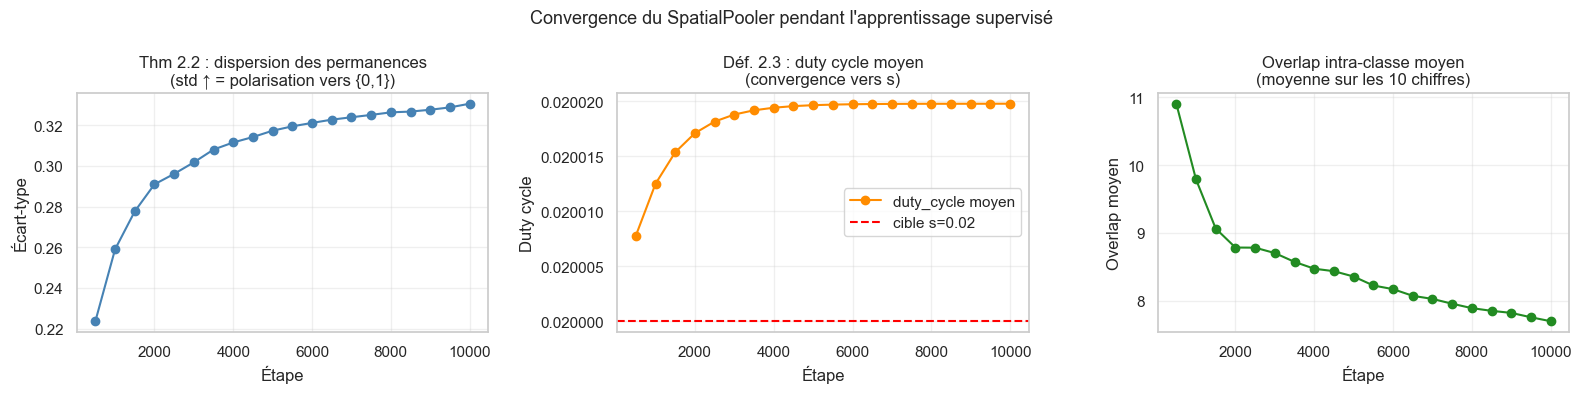

In [25]:

# ═══ Hyperparamètres d'entraînement ═══
N_IN = 784
N_MC = 2048
S = 0.02
N_TRAIN = 10000
LOG_EVERY = 500

# On réutilise exactement la convention d'apprentissage hebbienne du module principal.
pooler = SpatialPooler(
    N_in=N_IN,
    N_mc=N_MC,
    s=S,
    tau_conn=0.5,
    beta=1.0,
    T_w=1000,
    delta_p_plus=0.05,
    delta_p_minus=0.03,
).to(DEVICE)

# Copie figée avant apprentissage pour comparer avant / après.
pooler_before = copy.deepcopy(pooler).to(DEVICE)
prototype_space = SDRSpace(n=N_MC, w=pooler.k)

train_indices = torch.randperm(len(train_dataset))[:N_TRAIN].tolist()

class_prototypes, training_log = supervised_hebbian_training(
    pooler=pooler,
    dataset=train_dataset,
    indices=train_indices,
    device=DEVICE,
    log_every=LOG_EVERY,
)

final_intra_by_digit = {
    digit: mean_pairwise_overlap(sdrs)
    for digit, sdrs in class_prototypes.items()
}
final_intra_mean = float(np.nanmean(list(final_intra_by_digit.values())))

print("\nRésumé final de l'entraînement :")
print(f"  N_TRAIN = {N_TRAIN}")
print(f"  k       = {pooler.k}")
print(f"  duty_cycle moyen final = {pooler.duty_cycle.mean().item():.4f}")
print(f"  overlap intra moyen final = {final_intra_mean:.2f} bits")

# ═══ Visualisation de convergence (Thm 2.2) ═══
steps = training_log["step"]
perm_std_hist = training_log["perm_std"]
duty_mean_hist = training_log["duty_mean"]
intra_mean_hist = training_log["intra_mean"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(steps, perm_std_hist, marker="o", color="steelblue")
axes[0].set_title("Thm 2.2 : dispersion des permanences\n(std ↑ = polarisation vers {0,1})")
axes[0].set_xlabel("Étape")
axes[0].set_ylabel("Écart-type")
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, duty_mean_hist, marker="o", color="darkorange", label="duty_cycle moyen")
axes[1].axhline(S, color="red", linestyle="--", label=f"cible s={S}")
axes[1].set_title("Déf. 2.3 : duty cycle moyen\n(convergence vers s)")
axes[1].set_xlabel("Étape")
axes[1].set_ylabel("Duty cycle")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(steps, intra_mean_hist, marker="o", color="forestgreen")
axes[2].set_title("Overlap intra-classe moyen\n(moyenne sur les 10 chiffres)")
axes[2].set_xlabel("Étape")
axes[2].set_ylabel("Overlap moyen")
axes[2].grid(True, alpha=0.3)

plt.suptitle("Convergence du SpatialPooler pendant l'apprentissage supervisé", fontsize=13)
plt.tight_layout()
plt.show()


# 2. Classification par plus proche voisin SDR

On construit un prototype par classe, puis on prédit le label du test par `argmax overlap(sdr_test, prototype_k)`.

Accuracy globale sur 1000 images de test : 61.600%


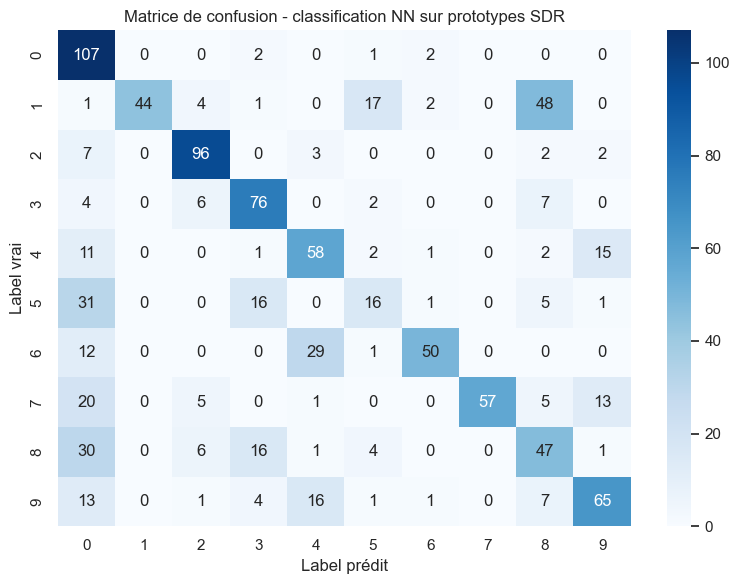

⚠️ Warning : accuracy sous 70 %
Les 3 classes les plus confondues :
  1 ↔ 8 : 48 erreurs combinées
  0 ↔ 5 : 32 erreurs combinées
  4 ↔ 9 : 31 erreurs combinées


In [26]:
N_TEST = 1000

# On prélève un sous-ensemble de test fixe pour la comparaison.
test_indices = torch.randperm(len(test_dataset))[:N_TEST].tolist()
learned_prototypes = build_class_prototypes(class_prototypes, prototype_space)

y_true, y_pred, confusion, accuracy = evaluate_classifier(
    pooler=pooler,
    dataset=test_dataset,
    indices=test_indices,
    prototypes=learned_prototypes,
    sdr_space=prototype_space,
    device=DEVICE,
)

print(f"Accuracy globale sur {N_TEST} images de test : {accuracy:.3%}")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(range(10)),
    yticklabels=list(range(10)),
    ax=ax,
)
ax.set_title("Matrice de confusion - classification NN sur prototypes SDR")
ax.set_xlabel("Label prédit")
ax.set_ylabel("Label vrai")
plt.tight_layout()
plt.show()

if accuracy < 0.70:
    print("⚠️ Warning : accuracy sous 70 %")
    print("Les 3 classes les plus confondues :")
    for i, j, score in top_confused_pairs(confusion, top_k=3):
        print(f"  {i} ↔ {j} : {score} erreurs combinées")

# 3. Matrice d'overlap inter-classes

On compare les prototypes de classes avant et après apprentissage, puis on met en évidence les paires de chiffres les plus proches dans l'espace SDR.

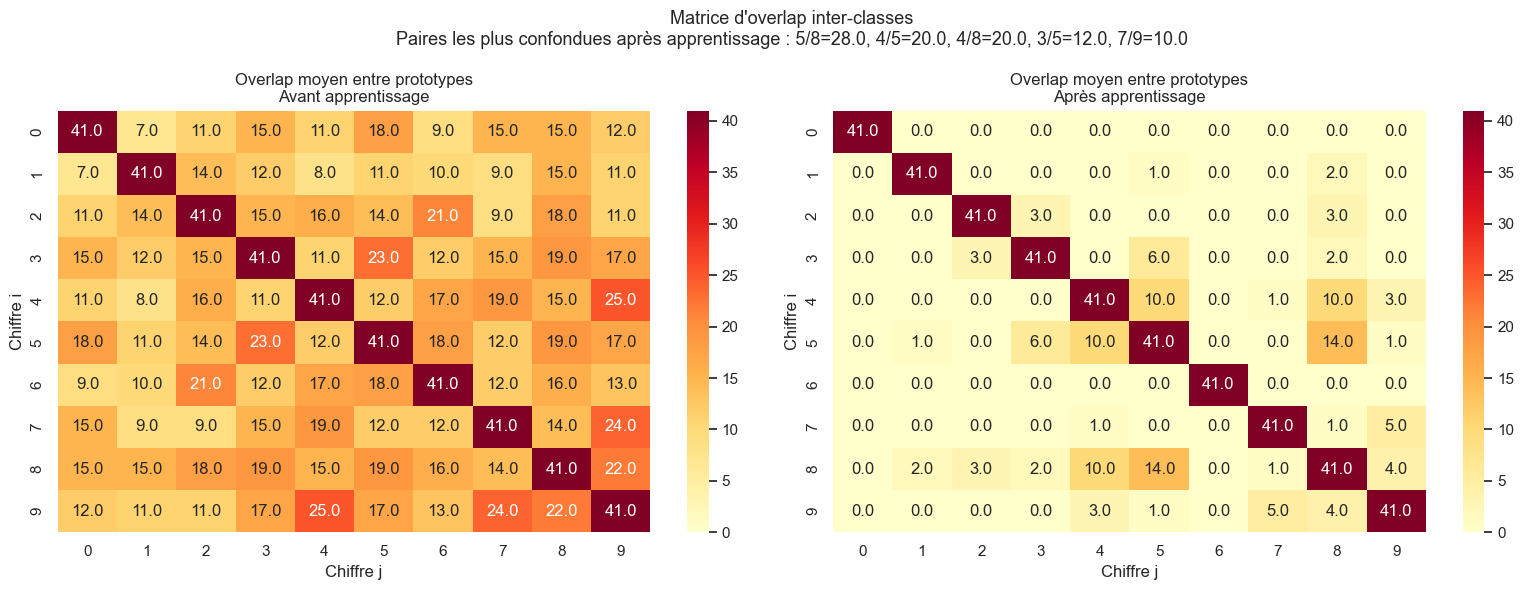

Overlap inter moyen avant apprentissage : 14.64 bits
Overlap inter moyen après apprentissage : 1.47 bits
Paires les plus confondues après apprentissage :
  5 / 8 -> 28.0 bits
  4 / 5 -> 20.0 bits
  4 / 8 -> 20.0 bits
  3 / 5 -> 12.0 bits
  7 / 9 -> 10.0 bits


In [27]:

# Sous-ensemble équilibré pour la comparaison avant / après.
probe_samples_by_class = collect_samples_by_class(train_dataset, n_per_class=80)

before_encoded = encode_samples_by_class(pooler_before, probe_samples_by_class, DEVICE)
after_encoded = encode_samples_by_class(pooler, probe_samples_by_class, DEVICE)

before_prototypes = build_class_prototypes(before_encoded, prototype_space)
after_prototypes = build_class_prototypes(after_encoded, prototype_space)

overlap_before = prototype_overlap_matrix(before_prototypes, prototype_space)
overlap_after = prototype_overlap_matrix(after_prototypes, prototype_space)

mean_inter_before = float(overlap_before[np.triu_indices(10, 1)].mean())
mean_inter_after = float(overlap_after[np.triu_indices(10, 1)].mean())

most_confused_after = top_confused_pairs(overlap_after, top_k=5)
confusion_pairs_text = ", ".join(f"{i}/{j}={score:.1f}" for i, j, score in most_confused_after)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, matrix, title in zip(
    axes,
    [overlap_before, overlap_after],
    ["Avant apprentissage", "Après apprentissage"],
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        xticklabels=list(range(10)),
        yticklabels=list(range(10)),
        ax=ax,
        vmin=0,
        vmax=max(overlap_before.max(), overlap_after.max()),
    )
    ax.set_title(f"Overlap moyen entre prototypes\n{title}")
    ax.set_xlabel("Chiffre j")
    ax.set_ylabel("Chiffre i")

plt.suptitle(
    f"Matrice d'overlap inter-classes\nPaires les plus confondues après apprentissage : {confusion_pairs_text}",
    fontsize=13,
)
plt.tight_layout()
plt.show()

print(f"Overlap inter moyen avant apprentissage : {mean_inter_before:.2f} bits")
print(f"Overlap inter moyen après apprentissage : {mean_inter_after:.2f} bits")
print("Paires les plus confondues après apprentissage :")
for i, j, score in most_confused_after:
    print(f"  {i} / {j} -> {score:.1f} bits")


# 4. Capacité (Prop. 1.1)

On teste combien d'objets distincts le `SpatialPooler` peut mémoriser sans collision. Une collision est comptée si deux SDR encodés différents ont un overlap supérieur ou égal à `θ = 10`.

N= 100 | collisions=     52 | collision_rate=1.0505%
N= 500 | collisions=   1834 | collision_rate=1.4701%
N=1000 | collisions=   6931 | collision_rate=1.3876%
N=2000 | collisions=  26616 | collision_rate=1.3315%
N=5000 | collisions= 168797 | collision_rate=1.3506%


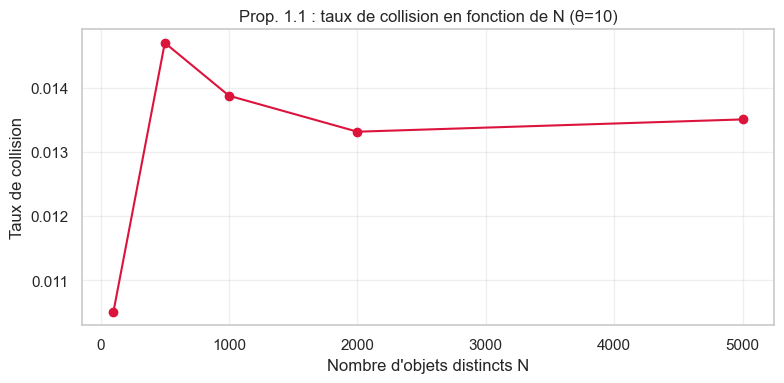

In [28]:
N_VALUES = [100, 500, 1000, 2000, 5000]
INPUT_W = 64
THETA = 10

cap_input_space = SDRSpace(n=N_IN, w=INPUT_W)
capacity_results = []
collision_rates = []

for N in N_VALUES:
    raw_objects = generate_random_objects(N, cap_input_space, DEVICE)
    collisions, collision_rate = estimate_collision_rate(pooler, raw_objects, theta=THETA)
    capacity_results.append(
        {
            "N": N,
            "collisions": collisions,
            "collision_rate": collision_rate,
        }
    )
    collision_rates.append(collision_rate)
    print(f"N={N:4d} | collisions={collisions:7d} | collision_rate={collision_rate:.4%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(N_VALUES, collision_rates, marker="o", color="crimson")
ax.set_title(f"Prop. 1.1 : taux de collision en fonction de N (θ={THETA})")
ax.set_xlabel("Nombre d'objets distincts N")
ax.set_ylabel("Taux de collision")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Bilan

Tableau récapitulatif des mesures principales du notebook.

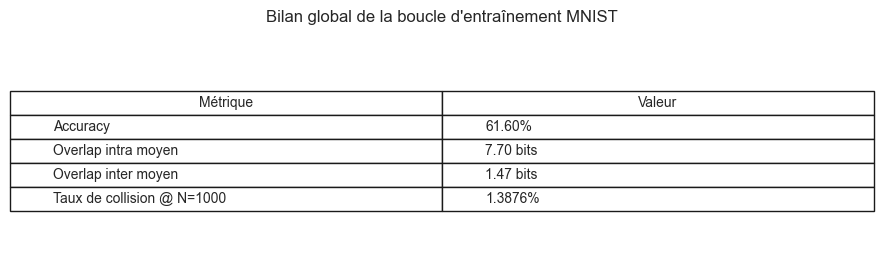

In [29]:
collision_rate_1000 = next(item["collision_rate"] for item in capacity_results if item["N"] == 1000)
summary_rows = [
    ["Accuracy", f"{accuracy:.2%}"],
    ["Overlap intra moyen", f"{final_intra_mean:.2f} bits"],
    ["Overlap inter moyen", f"{mean_inter_after:.2f} bits"],
    ["Taux de collision @ N=1000", f"{collision_rate_1000:.4%}"],
]

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.axis("off")
table = ax.table(
    cellText=summary_rows,
    colLabels=["Métrique", "Valeur"],
    cellLoc="left",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
ax.set_title("Bilan global de la boucle d'entraînement MNIST", pad=18)
plt.tight_layout()
plt.show()